# ML Homework 4 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW4.ipynb" to "HW4_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together
6. Upload the saved confusion matrix image file together

# [HW 4] Grid search for CNN

1. Load the 'AccData.csv' file as you loaded in the 'ML7_Code2'.
2. Prepare training and test dataset with the test data ratio of """30%""".
3. Perform a grid search to find the best combination of hyperparameters for the CNN model.
  - You can create any combination of hyperparameters.
  - Do not copy 'ML7_Code2' exactly. Set at least one other hyperparamter as the grid search target.
4. Determine your best CNN model based on classification accuracy.
5. Plot a confusion matrix for the best model and save it as an image file (.png or .jpg).
  - Search how to save a figure as an image file.
  - Upload the confusion matrix image to BrightSpace with ipynb and pdf files

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import metrics

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [33]:
# Load AccData.csv directly from GitHub (same as ML7_Code2)
AccData_pd_load = pd.read_csv(
    'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset_Acc/AccData.csv?raw=true'
).iloc[:, 1:]

print('AccData shape:', AccData_pd_load.shape)
AccData = np.array(AccData_pd_load)

# Convert raw acceleration signals to 2D spectrogram images via STFT
Fs = 12800  # Sampling frequency in Hz
f, t, AccSTFT = signal.spectrogram(AccData, Fs, nperseg=78, noverlap=10)
print('AccSTFT shape:', AccSTFT.shape)

AccData shape: (360, 2774)
AccSTFT shape: (360, 40, 40)


In [34]:
NoOfData = 180  # 180 normal, 180 abnormal samples

NormalSet   = AccSTFT[:NoOfData]
AbnormalSet = AccSTFT[NoOfData:]

# Reshape to (samples, freq_bins, time_steps, channels)
NoOfSensor  = 1
NormalSet   = NormalSet.reshape(  NormalSet.shape[0],   NormalSet.shape[1],   NormalSet.shape[2], NoOfSensor)
AbnormalSet = AbnormalSet.reshape(AbnormalSet.shape[0], AbnormalSet.shape[1], AbnormalSet.shape[2], NoOfSensor)

print('NormalSet shape  :', NormalSet.shape)
print('AbnormalSet shape:', AbnormalSet.shape)

# Test data ratio: 30%
TestData_Ratio = 0.30

TrainData_Nor, TestData_Nor = train_test_split(NormalSet,   test_size=TestData_Ratio, random_state=777)
TrainData_Abn, TestData_Abn = train_test_split(AbnormalSet, test_size=TestData_Ratio, random_state=777)

print('Train Normal / Test Normal    :', TrainData_Nor.shape, TestData_Nor.shape)
print('Train Abnormal / Test Abnormal:', TrainData_Abn.shape, TestData_Abn.shape)

NormalSet shape  : (180, 40, 40, 1)
AbnormalSet shape: (180, 40, 40, 1)
Train Normal / Test Normal    : (126, 40, 40, 1) (54, 40, 40, 1)
Train Abnormal / Test Abnormal: (126, 40, 40, 1) (54, 40, 40, 1)


In [35]:
# One-hot encode labels: [1,0] = Normal, [0,1] = Abnormal
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0], 2))
TrainLabel_Abn = np.ones( (TrainData_Abn.shape[0], 2))
TestLabel_Nor  = np.zeros((TestData_Nor.shape[0],  2))
TestLabel_Abn  = np.ones( (TestData_Abn.shape[0],  2))

TrainLabel_Nor[:, 0] = 1  # [1, 0] -> Normal
TrainLabel_Abn[:, 0] = 0  # [0, 1] -> Abnormal
TestLabel_Nor[:, 0]  = 1
TestLabel_Abn[:, 0]  = 0

# Combine normal and abnormal
TrainData  = np.concatenate([TrainData_Nor,  TrainData_Abn],  axis=0)
TestData   = np.concatenate([TestData_Nor,   TestData_Abn],   axis=0)
TrainLabel = np.concatenate([TrainLabel_Nor, TrainLabel_Abn], axis=0)
TestLabel  = np.concatenate([TestLabel_Nor,  TestLabel_Abn],  axis=0)

print('TrainData / TestData  :', TrainData.shape,  TestData.shape)
print('TrainLabel / TestLabel:', TrainLabel.shape, TestLabel.shape)

TrainData / TestData  : (252, 40, 40, 1) (108, 40, 40, 1)
TrainLabel / TestLabel: (252, 2) (108, 2)


In [36]:
# Hyperparameters to search
param_FiltS   = [3, 5]           # filter (kernel) sizes
param_FiltN   = [4, 8]           # number of filters per conv layer
param_LRate   = [0.001, 0.0001]  # learning rates
param_Dropout = [0.0, 0.3]       # dropout rate  <-- extra hyperparameter

# Fixed hyperparameters
noOfNeuron = 16
Stride     = 1
Epoch      = 300

NoOfCases = len(param_FiltS) * len(param_FiltN) * len(param_LRate) * len(param_Dropout)
print(f'Total grid search cases: {NoOfCases}')

def CNN_model(input_shape, noOfNeuron, learningRate, filterSize, numOfFilters, dropoutRate, stride=1):
    """Build and compile a 2-layer CNN for binary classification."""
    model = keras.Sequential([
        # Conv block 1
        layers.Conv2D(filters=numOfFilters,
                      kernel_size=(filterSize, filterSize),
                      strides=(stride, stride),
                      activation='relu',
                      padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Conv block 2
        layers.Conv2D(filters=numOfFilters * 2,
                      kernel_size=(filterSize, filterSize),
                      strides=(stride, stride),
                      activation='relu',
                      padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Fully connected head
        layers.Flatten(),
        layers.Dense(noOfNeuron, activation='relu'),
        layers.Dropout(dropoutRate),
        layers.Dense(2, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learningRate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

Total grid search cases: 16


In [37]:
Accuracy_df = pd.DataFrame(
    np.zeros(shape=(NoOfCases, 5)),
    columns=['filter size', 'number of filters', 'learning rate', 'dropout rate', 'Accuracy']
)

input_shape = TrainData.shape[1:]  # (freq_bins, time_steps, 1)
cnt = 0

for filtS in param_FiltS:
    for filtN in param_FiltN:
        for lrate in param_LRate:
            for dropout in param_Dropout:
                print(f'[{cnt+1}/{NoOfCases}] FilterSize={filtS}  NumFilters={filtN}  LR={lrate}  Dropout={dropout}')

                model = CNN_model(input_shape,
                                  noOfNeuron   = noOfNeuron,
                                  learningRate = lrate,
                                  filterSize   = filtS,
                                  numOfFilters = filtN,
                                  dropoutRate  = dropout,
                                  stride       = Stride)

                model.fit(TrainData, TrainLabel,
                          epochs=Epoch,
                          batch_size=32,
                          validation_split=0.1,
                          verbose=0)

                _, acc = model.evaluate(TestData, TestLabel, verbose=0)

                Accuracy_df.iloc[cnt, 0] = filtS
                Accuracy_df.iloc[cnt, 1] = filtN
                Accuracy_df.iloc[cnt, 2] = lrate
                Accuracy_df.iloc[cnt, 3] = dropout
                Accuracy_df.iloc[cnt, 4] = acc

                model.save(f'CNN_FS{filtS}_FN{filtN}_LR{lrate:.4f}_DO{dropout}.h5')
                cnt += 1

Accuracy_df

[1/16] FilterSize=3  NumFilters=4  LR=0.001  Dropout=0.0


[2/16] FilterSize=3  NumFilters=4  LR=0.001  Dropout=0.3


[3/16] FilterSize=3  NumFilters=4  LR=0.0001  Dropout=0.0


[4/16] FilterSize=3  NumFilters=4  LR=0.0001  Dropout=0.3


[5/16] FilterSize=3  NumFilters=8  LR=0.001  Dropout=0.0


...

[13/16] FilterSize=5  NumFilters=8  LR=0.001  Dropout=0.0


[14/16] FilterSize=5  NumFilters=8  LR=0.001  Dropout=0.3


[15/16] FilterSize=5  NumFilters=8  LR=0.0001  Dropout=0.0


[16/16] FilterSize=5  NumFilters=8  LR=0.0001  Dropout=0.3


,filter size,number of filters,learning rate,dropout rate,Accuracy
0,3.0,4.0,0.0010,0.0,0.500000
1,3.0,4.0,0.0010,0.3,0.592593
2,3.0,4.0,0.0001,0.0,0.500000
3,3.0,4.0,0.0001,0.3,0.509259
4,3.0,8.0,0.0010,0.0,0.972222
5,3.0,8.0,0.0010,0.3,0.879630
6,3.0,8.0,0.0001,0.0,0.527778
7,3.0,8.0,0.0001,0.3,0.833333
8,5.0,4.0,0.0010,0.0,0.962963
9,5.0,4.0,0.0010,0.3,0.972222


In [41]:
# Rank all combinations by test accuracy
ranked_results = Accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Extract top-performing hyperparameters
top_filtS   = int(ranked_results.iloc[0, 0])
top_filtN   = int(ranked_results.iloc[0, 1])
top_lrate   = ranked_results.iloc[0, 2]
top_dropout = ranked_results.iloc[0, 3]
top_acc     = ranked_results.iloc[0, 4]

print('=' * 40)
print('       GRID SEARCH RESULTS SUMMARY')
print('=' * 40)
print(f'  Kernel Size      -> {top_filtS} x {top_filtS}')
print(f'  Conv Filters     -> {top_filtN}')
print(f'  Learning Rate    -> {top_lrate}')
print(f'  Dropout          -> {top_dropout}')
print(f'  Best Accuracy    -> {top_acc:.4f}  ({top_acc*100:.2f}%)')
print('=' * 40)

# Average accuracy grouped by each hyperparameter
summary = {
    'Kernel Size'    : Accuracy_df.groupby('filter size'),
    'Num Filters'    : Accuracy_df.groupby('number of filters'),
    'Learning Rate'  : Accuracy_df.groupby('learning rate'),
    'Dropout Rate'   : Accuracy_df.groupby('dropout rate'),
}

print('\n-- Mean Accuracy per Hyperparameter --')
for label, group in summary.items():
    stats = group['Accuracy'].agg(['mean', 'std']).reset_index()
    print(f'\n  [{label}]')
    for _, row in stats.iterrows():
        col_val = row.iloc[0]
        print(f'    {col_val:<10}  mean={row["mean"]:.4f}  std={row["std"]:.4f}')

       GRID SEARCH RESULTS SUMMARY
  Kernel Size      -> 3 x 3
  Conv Filters     -> 8
  Learning Rate    -> 0.001
  Dropout          -> 0.0
  Best Accuracy    -> 0.9722  (97.22%)

-- Mean Accuracy per Hyperparameter --

  [Kernel Size]
    3.0         mean=0.6644  std=0.1970
    5.0         mean=0.9051  std=0.1317

  [Num Filters]
    4.0         mean=0.6968  std=0.2212
    8.0         mean=0.8727  std=0.1505

  [Learning Rate]
    0.0001      mean=0.7164  std=0.2029
    0.001       mean=0.8530  std=0.1935

  [Dropout Rate]
    0.0         mean=0.7361  std=0.2249
    0.3         mean=0.8333  std=0.1824


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Saved: confusion_matrix_best_CNN.png


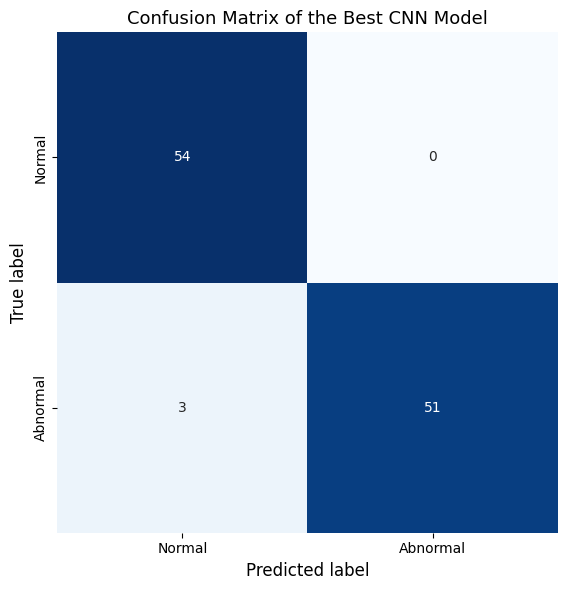

In [39]:
best_model_name = f'CNN_FS{Best_FiltS}_FN{Best_FiltN}_LR{Best_LRate:.4f}_DO{Best_Dropout}.h5'
best_cnn_model  = keras.models.load_model(best_model_name)

Predicted     = best_cnn_model.predict(TestData)
TestLabel_rev = np.argmax(TestLabel,  axis=1)
Predicted_rev = np.argmax(Predicted, axis=1)

cm = confusion_matrix(TestLabel_rev, Predicted_rev)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues,
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'],
            cbar=False, square=True)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label',      fontsize=12)
plt.title('Confusion Matrix of the Best CNN Model', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_best_CNN.png', dpi=150)
print('Saved: confusion_matrix_best_CNN.png')
plt.show()

In [42]:
acc_score = metrics.accuracy_score( TestLabel_rev, Predicted_rev)
prec      = metrics.precision_score(TestLabel_rev, Predicted_rev)
rec       = metrics.recall_score(   TestLabel_rev, Predicted_rev)
f1        = metrics.f1_score(       TestLabel_rev, Predicted_rev)

print('=' * 40)
print('     MODEL PERFORMANCE METRICS')
print('=' * 40)
print(f'  Accuracy   ->  {acc_score:.4f}  ({acc_score*100:.2f}%)')
print(f'  Precision  ->  {prec:.4f}')
print(f'  Recall     ->  {rec:.4f}')
print(f'  F1 Score   ->  {f1:.4f}')
print('=' * 40)

     MODEL PERFORMANCE METRICS
  Accuracy   ->  0.9722  (97.22%)
  Precision  ->  1.0000
  Recall     ->  0.9444
  F1 Score   ->  0.9714


## ML7 and ML8 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML7 and ML8.

---

Write down A1 here.

---

### Q2. What skills did you have to develop to accomplish this project?

---

Wirte down A2 here.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Wirte down A3 here.

---

### Q4. What challenges did you encounter in completing the project?

---

Wirte down A4 here.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

Wirte down A5 here.

---